In [1]:
# CELL 1
!pip install timm h5py scikit-learn --quiet

import torch

print(f'PyTorch: {torch.__version__}')
print(f'CUDA: {torch.cuda.is_available()}')

if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

PyTorch: 2.10.0+cu128
CUDA: True
GPU: NVIDIA A100-SXM4-40GB


In [2]:
# CELL 2
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# CELL 3
from google.colab import files

files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d awsaf49/brats2020-training-data -p /content/brats2020 --unzip

print('Download complete!')

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/awsaf49/brats2020-training-data
License(s): CC0-1.0
100% 6.76G/6.76G [00:31<00:00, 230MB/s]

Download complete!


In [4]:
# CELL 4
import os

DATA_ROOT = '/content/brats2020'

for root, dirs, flist in os.walk(DATA_ROOT):
    level = root.replace(DATA_ROOT, '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')

    if level < 2:
        sub = '  ' * (level + 1)
        for f in flist[:5]:
            print(f'{sub}{f}')

brats2020/
  BraTS20 Training Metadata.csv
  BraTS2020_training_data/
    content/
      data/


In [5]:
# CELL 5
import os, random, time, glob, warnings, re
import numpy as np
import pandas as pd
import h5py

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms.functional as TF
import timm

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, f1_score, precision_score,
    recall_score, accuracy_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, precision_recall_curve,
    average_precision_score
)

import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'Device: {DEVICE}')

Device: cuda


In [6]:
# CELL 6
CFG = {
    'data_root':       '/content/brats2020',
    'csv_path':        '/content/brats2020/BraTS20 Training Metadata.csv',
    'h5_dir':          '/content/brats2020',

    'img_size':        224,
    'num_slices':      155,
    'num_channels':    4,
    'num_classes':     3,

    'backbone':        'vit_base_patch16_224',
    'embed_dim':       768,

    'epochs':          30,
    'batch_size':      2,

    'lr_backbone':     1e-5,
    'lr_head':         1e-4,

    'weight_decay':    1e-4,
    'dropout':         0.3,
    'patience':        7,

    'train_frac':      0.70,
    'val_frac':        0.15,
    'test_frac':       0.15,

    'num_workers':     2,
    'pin_memory':      True,
    'mixed_precision': True,

    'slice_chunk_size': 16,

    'checkpoint_path': '/content/vit_b16_meanpool_best.pth',
}

CLASS_NAMES = ['NCR', 'ED', 'ET']

print('Config ready.')

Config ready.


In [7]:
# CELL 7
df = pd.read_csv(CFG['csv_path'])

print(f'CSV shape: {df.shape}')
print(df.head())
print('Columns:', df.columns.tolist())

CSV shape: (57195, 8)
                                          slice_path  target  volume  slice  \
0  ../input/brats2020-training-data/BraTS2020_tra...       0      41      0   
1  ../input/brats2020-training-data/BraTS2020_tra...       0      41      1   
2  ../input/brats2020-training-data/BraTS2020_tra...       0      41      2   
3  ../input/brats2020-training-data/BraTS2020_tra...       0      41      3   
4  ../input/brats2020-training-data/BraTS2020_tra...       0      41      4   

   label0_pxl_cnt  label1_pxl_cnt  label2_pxl_cnt  background_ratio  
0               0               0               0               1.0  
1               0               0               0               1.0  
2               0               0               0               1.0  
3               0               0               0               1.0  
4               0               0               0               1.0  
Columns: ['slice_path', 'target', 'volume', 'slice', 'label0_pxl_cnt', 'label1_pxl_

In [8]:
# CELL 8
ID_COL = 'volume'

# Correct mapping:
# NCR = label0
# ED  = label1
# ET  = label2

NCR_COL = 'label0_pxl_cnt'
ED_COL  = 'label1_pxl_cnt'
ET_COL  = 'label2_pxl_cnt'

for col in [NCR_COL, ED_COL, ET_COL]:
    assert col in df.columns, f'{col} not found'

patient_df = df.groupby(ID_COL).agg(
    ncr_total = (NCR_COL, 'sum'),
    ed_total  = (ED_COL,  'sum'),
    et_total  = (ET_COL,  'sum'),
).reset_index()

patient_df['NCR'] = (patient_df['ncr_total'] > 0).astype(int)
patient_df['ED']  = (patient_df['ed_total']  > 0).astype(int)
patient_df['ET']  = (patient_df['et_total']  > 0).astype(int)

patient_df = patient_df[[ID_COL, 'NCR', 'ED', 'ET']]
patient_df = patient_df.rename(columns={ID_COL: 'patient_id'})

print(patient_df.head())
print(patient_df[['NCR', 'ED', 'ET']].sum())

   patient_id  NCR  ED  ET
0           1    1   1   1
1           2    1   1   1
2           3    1   1   1
3           4    1   1   1
4           5    1   1   1
NCR    368
ED     368
ET     342
dtype: int64


In [9]:
# CELL 9
h5_files = glob.glob(os.path.join(CFG['h5_dir'], '**', '*.h5'), recursive=True)

print(f'Found {len(h5_files)} h5 files')

h5_map = {}

for fpath in h5_files:
    m = re.match(r'volume_(\d+)_slice_(\d+)\.h5', os.path.basename(fpath))
    if m:
        vid = int(m.group(1))
        h5_map.setdefault(vid, []).append(fpath)

for vid in h5_map:
    h5_map[vid].sort(
        key=lambda p: int(re.search(r'slice_(\d+)', p).group(1))
    )

patient_df['patient_id'] = patient_df['patient_id'].astype(int)
h5_map = {int(k): v for k, v in h5_map.items()}

patient_df = patient_df[
    patient_df['patient_id'].isin(h5_map)
].reset_index(drop=True)

patient_df['h5_paths'] = patient_df['patient_id'].map(h5_map)

print(f'Matched patients: {len(patient_df)}')
print(patient_df['h5_paths'].apply(len).head())

Found 57195 h5 files
Matched patients: 369
0    155
1    155
2    155
3    155
4    155
Name: h5_paths, dtype: int64


In [10]:
# CELL 10
train_val_df, test_df = train_test_split(
    patient_df,
    test_size=CFG['test_frac'],
    random_state=SEED,
    shuffle=True
)

val_size = CFG['val_frac'] / (CFG['train_frac'] + CFG['val_frac'])

train_df, val_df = train_test_split(
    train_val_df,
    test_size=val_size,
    random_state=SEED,
    shuffle=True
)

print(f'Train: {len(train_df)}')
print(f'Val: {len(val_df)}')
print(f'Test: {len(test_df)}')

Train: 257
Val: 56
Test: 56


In [11]:
# CELL 11
class BraTS2020Dataset(Dataset):
    def __init__(self, df, img_size=224, num_slices=155, augment=False):
        self.df = df.reset_index(drop=True)
        self.img_size = img_size
        self.num_slices = num_slices
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def _load_slice(self, path):
        with h5py.File(path, 'r') as f:
            img = f['image'][()]

        img = img.transpose(2, 0, 1).astype(np.float32)

        for c in range(img.shape[0]):
            mn = img[c].min()
            mx = img[c].max()

            if mx > mn:
                img[c] = (img[c] - mn) / (mx - mn)

        t = torch.from_numpy(img)

        t = F.interpolate(
            t.unsqueeze(0),
            size=(self.img_size, self.img_size),
            mode='bilinear',
            align_corners=False
        ).squeeze(0)

        return t

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        label = torch.tensor(
            [row['NCR'], row['ED'], row['ET']],
            dtype=torch.float32
        )

        paths = row['h5_paths']

        if len(paths) >= self.num_slices:
            idxs = np.linspace(
                0,
                len(paths) - 1,
                self.num_slices
            ).astype(int)

            selected_paths = [paths[i] for i in idxs]

        else:
            selected_paths = list(paths)

            while len(selected_paths) < self.num_slices:
                selected_paths.append(paths[-1])

        volume = []

        for p in selected_paths:
            sl = self._load_slice(p)
            volume.append(sl)

        volume = torch.stack(volume, dim=0)

        if self.augment:
            if random.random() < 0.5:
                volume = torch.flip(volume, dims=[3])

            if random.random() < 0.5:
                volume = torch.flip(volume, dims=[2])

        return volume, label

In [12]:
# CELL 12
train_dataset = BraTS2020Dataset(
    train_df,
    img_size=CFG['img_size'],
    num_slices=CFG['num_slices'],
    augment=True
)

val_dataset = BraTS2020Dataset(
    val_df,
    img_size=CFG['img_size'],
    num_slices=CFG['num_slices'],
    augment=False
)

test_dataset = BraTS2020Dataset(
    test_df,
    img_size=CFG['img_size'],
    num_slices=CFG['num_slices'],
    augment=False
)

train_loader = DataLoader(
    train_dataset,
    batch_size=CFG['batch_size'],
    shuffle=True,
    num_workers=CFG['num_workers'],
    pin_memory=CFG['pin_memory']
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CFG['batch_size'],
    shuffle=False,
    num_workers=CFG['num_workers'],
    pin_memory=CFG['pin_memory']
)

test_loader = DataLoader(
    test_dataset,
    batch_size=CFG['batch_size'],
    shuffle=False,
    num_workers=CFG['num_workers'],
    pin_memory=CFG['pin_memory']
)

print(f'Train batches: {len(train_loader)}')
print(f'Val batches: {len(val_loader)}')
print(f'Test batches: {len(test_loader)}')

Train batches: 129
Val batches: 28
Test batches: 28


In [13]:
# CELL 13
class ViTB16MeanPoolingClassifier(nn.Module):
    def __init__(
        self,
        num_classes=3,
        dropout=0.3,
        slice_chunk_size=16
    ):
        super().__init__()

        self.slice_chunk_size = slice_chunk_size

        self.backbone = timm.create_model(
            'vit_base_patch16_224',
            pretrained=True,
            num_classes=0,
            global_pool='avg',
            in_chans=4
        )

        embed_dim = self.backbone.num_features

        self.head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Dropout(dropout),
            nn.Linear(embed_dim, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Dropout(dropout / 2),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        B, S, C, H, W = x.shape

        all_features = []

        for start in range(0, S, self.slice_chunk_size):
            end = min(start + self.slice_chunk_size, S)

            x_chunk = x[:, start:end]

            chunk_size = x_chunk.shape[1]

            x_chunk = x_chunk.reshape(B * chunk_size, C, H, W)

            feat_chunk = self.backbone(x_chunk)

            feat_chunk = feat_chunk.reshape(B, chunk_size, -1)

            all_features.append(feat_chunk)

        features = torch.cat(all_features, dim=1)

        pooled_features = features.mean(dim=1)

        logits = self.head(pooled_features)

        return logits, None

In [14]:
# CELL 14
model = ViTB16MeanPoolingClassifier(
    num_classes=CFG['num_classes'],
    dropout=CFG['dropout'],
    slice_chunk_size=CFG['slice_chunk_size']
).to(DEVICE)

total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'Total params: {total:,}')
print(f'Trainable params: {trainable:,}')

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Total params: 86,226,947
Trainable params: 86,226,947


In [15]:
# CELL 15
with torch.no_grad():
    dummy = torch.randn(1, 10, 4, 224, 224).to(DEVICE)

    logits, attn = model(dummy)

print(f'Logits shape: {logits.shape}')
print(f'Attention: {attn}')

Logits shape: torch.Size([1, 3])
Attention: None


In [16]:
# CELL 16
n = len(train_df)

pos_weights = torch.tensor([
    (n - train_df['NCR'].sum()) / (train_df['NCR'].sum() + 1e-6),
    (n - train_df['ED'].sum())  / (train_df['ED'].sum()  + 1e-6),
    (n - train_df['ET'].sum())  / (train_df['ET'].sum()  + 1e-6),
], dtype=torch.float32).to(DEVICE)

print(f'pos_weights: {pos_weights.cpu().tolist()}')

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights)

pos_weights: [0.00390625, 0.00390625, 0.08438818901777267]


In [17]:
# CELL 17
optimizer = torch.optim.AdamW([
    {
        'params': model.backbone.parameters(),
        'lr': CFG['lr_backbone']
    },
    {
        'params': model.head.parameters(),
        'lr': CFG['lr_head']
    }
], weight_decay=CFG['weight_decay'])

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=CFG['epochs'],
    eta_min=1e-7
)

scaler = torch.cuda.amp.GradScaler(
    enabled=CFG['mixed_precision']
)

print('Loss, optimizer and scheduler ready.')

Loss, optimizer and scheduler ready.


In [18]:
# CELL 18
def train_one_epoch(model, loader, optimizer, criterion, scaler, device):
    model.train()

    total_loss = 0.0

    all_preds = []
    all_labels = []

    for i, (vols, labels) in enumerate(loader):
        vols = vols.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast(enabled=CFG['mixed_precision']):
            logits, _ = model(vols)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()

        scaler.unscale_(optimizer)

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        scaler.step(optimizer)

        scaler.update()

        total_loss += loss.item()

        preds = (torch.sigmoid(logits) >= 0.5).int().cpu().numpy()

        all_preds.append(preds)
        all_labels.append(labels.int().cpu().numpy())

        if (i + 1) % 10 == 0:
            print(f'Batch [{i + 1}/{len(loader)}] loss={loss.item():.4f}')

    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)

    macro_f1 = f1_score(
        all_labels,
        all_preds,
        average='macro',
        zero_division=0
    )

    avg_loss = total_loss / len(loader)

    return avg_loss, macro_f1

In [19]:
# CELL 19
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0

    all_preds = []
    all_labels = []
    all_probs = []

    for vols, labels in loader:
        vols = vols.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=CFG['mixed_precision']):
            logits, _ = model(vols)
            loss = criterion(logits, labels)

        total_loss += loss.item()

        probs = torch.sigmoid(logits).float().cpu().numpy()
        preds = (probs >= 0.5).astype(int)

        all_preds.append(preds)
        all_probs.append(probs)
        all_labels.append(labels.int().cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_probs = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)

    macro_f1 = f1_score(
        all_labels,
        all_preds,
        average='macro',
        zero_division=0
    )

    avg_loss = total_loss / len(loader)

    return avg_loss, macro_f1, all_preds, all_labels, all_probs

In [20]:
# CELL 20
history = {
    'train_loss': [],
    'val_loss': [],
    'train_f1': [],
    'val_f1': []
}

best_val_f1 = -1.0
patience_counter = 0

for epoch in range(1, CFG['epochs'] + 1):
    print(f'\nEpoch {epoch}/{CFG["epochs"]}')

    tr_loss, tr_f1 = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        scaler,
        DEVICE
    )

    vl_loss, vl_f1, _, _, _ = evaluate(
        model,
        val_loader,
        criterion,
        DEVICE
    )

    scheduler.step()

    print(f'Train Loss: {tr_loss:.4f} | Train F1: {tr_f1:.4f}')
    print(f'Val Loss:   {vl_loss:.4f} | Val F1:   {vl_f1:.4f}')

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_f1'].append(tr_f1)
    history['val_f1'].append(vl_f1)

    if vl_f1 > best_val_f1:
        best_val_f1 = vl_f1
        patience_counter = 0

        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_f1': best_val_f1,
            'history': history,
            'cfg': CFG
        }, CFG['checkpoint_path'])

        print(f'Best model saved with Val F1: {best_val_f1:.4f}')

    else:
        patience_counter += 1

        print(f'No improvement: {patience_counter}/{CFG["patience"]}')

        if patience_counter >= CFG['patience']:
            print('Early stopping triggered.')
            break


Epoch 1/30
Batch [10/129] loss=0.0104
Batch [20/129] loss=0.2733
Batch [30/129] loss=0.0156
Batch [40/129] loss=0.0166
Batch [50/129] loss=0.1436
Batch [60/129] loss=0.0192
Batch [70/129] loss=0.1298
Batch [80/129] loss=0.0219
Batch [90/129] loss=0.0210
Batch [100/129] loss=0.0234
Batch [110/129] loss=0.0187
Batch [120/129] loss=0.0157
Train Loss: 0.0446 | Train F1: 0.8385
Val Loss:   0.0377 | Val F1:   0.9877
Best model saved with Val F1: 0.9877

Epoch 2/30
Batch [10/129] loss=0.0146
Batch [20/129] loss=0.0170
Batch [30/129] loss=0.0178
Batch [40/129] loss=0.0168
Batch [50/129] loss=0.1452
Batch [60/129] loss=0.0164
Batch [70/129] loss=0.1798
Batch [80/129] loss=0.0178
Batch [90/129] loss=0.0187
Batch [100/129] loss=0.1878
Batch [110/129] loss=0.0180
Batch [120/129] loss=0.0196
Train Loss: 0.0406 | Train F1: 0.9354
Val Loss:   0.0361 | Val F1:   0.9877
No improvement: 1/7

Epoch 3/30
Batch [10/129] loss=0.1166
Batch [20/129] loss=0.0232
Batch [30/129] loss=0.0225
Batch [40/129] loss=

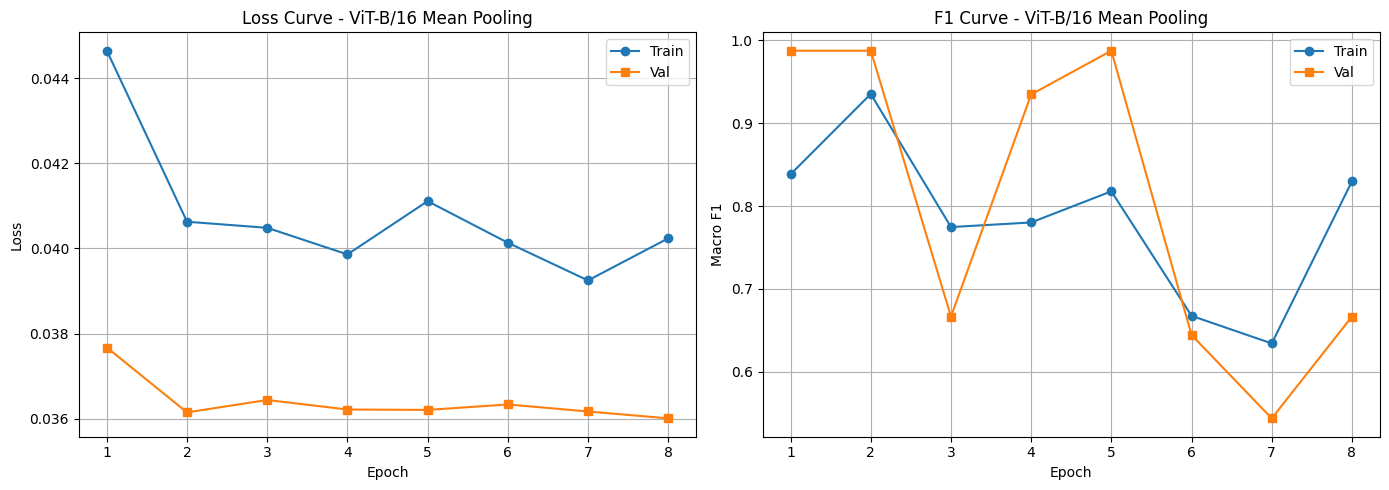

In [21]:
# CELL 21
epochs_ran = len(history['train_loss'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(range(1, epochs_ran + 1), history['train_loss'], 'o-', label='Train')
ax1.plot(range(1, epochs_ran + 1), history['val_loss'], 's-', label='Val')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss Curve - ViT-B/16 Mean Pooling')
ax1.legend()
ax1.grid(True)

ax2.plot(range(1, epochs_ran + 1), history['train_f1'], 'o-', label='Train')
ax2.plot(range(1, epochs_ran + 1), history['val_f1'], 's-', label='Val')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Macro F1')
ax2.set_title('F1 Curve - ViT-B/16 Mean Pooling')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('/content/training_curves_vit_b16_meanpool.png', dpi=150)
plt.show()

In [23]:
# CELL 22
ckpt = torch.load(CFG['checkpoint_path'], map_location=DEVICE)

model.load_state_dict(ckpt['model_state_dict'])

print(f'Loaded best model from epoch {ckpt["epoch"]}')
print(f'Best validation F1: {ckpt["val_f1"]:.4f}')

test_loss, test_f1, test_preds, test_labels, test_probs = evaluate(
    model,
    test_loader,
    criterion,
    DEVICE
)

print(f'Test Loss: {test_loss:.4f}')
print(f'Test Macro F1: {test_f1:.4f}')

print(
    classification_report(
        test_labels,
        test_preds,
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0
    )
)

Loaded best model from epoch 1
Best validation F1: 0.9877
Test Loss: 0.0318
Test Macro F1: 0.9908
              precision    recall  f1-score   support

         NCR     1.0000    1.0000    1.0000        56
          ED     1.0000    1.0000    1.0000        56
          ET     0.9464    1.0000    0.9725        53

   micro avg     0.9821    1.0000    0.9910       165
   macro avg     0.9821    1.0000    0.9908       165
weighted avg     0.9828    1.0000    0.9912       165
 samples avg     0.9821    1.0000    0.9893       165



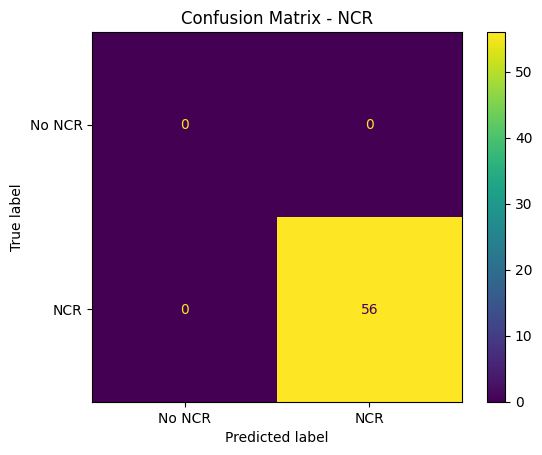

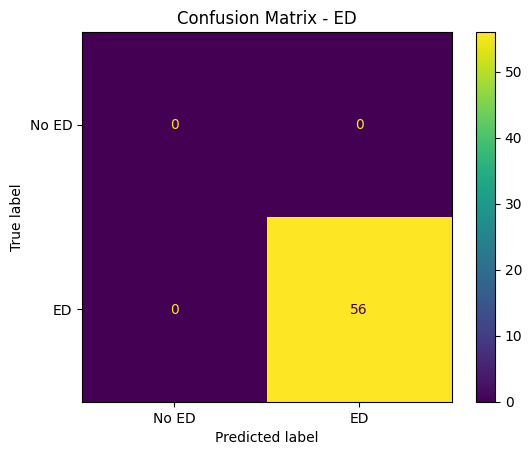

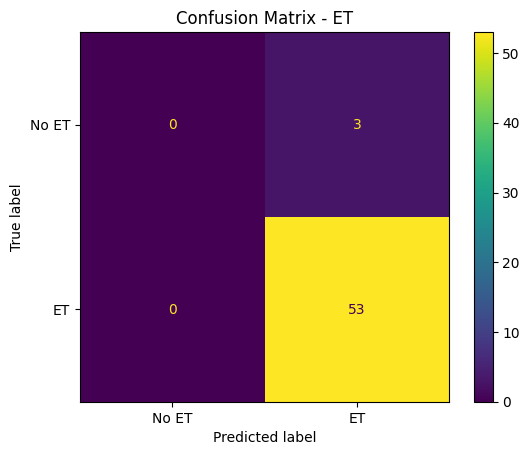

In [24]:
# CELL 23
for i, cls in enumerate(CLASS_NAMES):
    cm = confusion_matrix(
        test_labels[:, i],
        test_preds[:, i],
        labels=[0, 1]
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[f'No {cls}', cls]
    )

    disp.plot()

    plt.title(f'Confusion Matrix - {cls}')

    plt.savefig(f'/content/confusion_matrix_{cls}_vit_b16_meanpool.png', dpi=150)

    plt.show()

NCR: ROC not available
ED: ROC not available


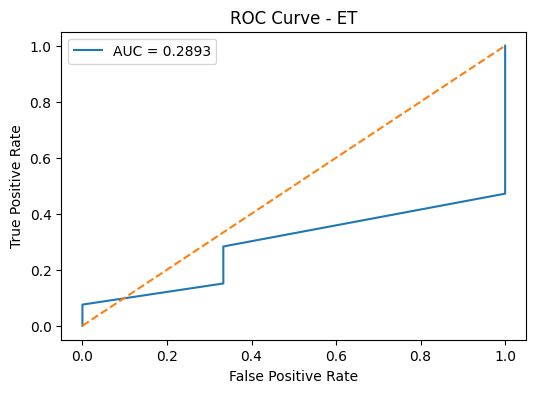

NCR: PR not available
ED: PR not available


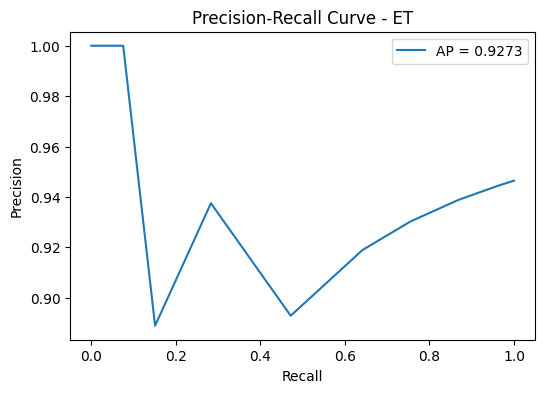

In [25]:
# CELL 24
for i, cls in enumerate(CLASS_NAMES):
    if len(np.unique(test_labels[:, i])) < 2:
        print(f'{cls}: ROC not available')
        continue

    fpr, tpr, _ = roc_curve(test_labels[:, i], test_probs[:, i])

    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6, 4))

    plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')

    plt.plot([0, 1], [0, 1], '--')

    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')

    plt.title(f'ROC Curve - {cls}')

    plt.legend()

    plt.savefig(f'/content/roc_curve_{cls}_vit_b16_meanpool.png', dpi=150)

    plt.show()


for i, cls in enumerate(CLASS_NAMES):
    if len(np.unique(test_labels[:, i])) < 2:
        print(f'{cls}: PR not available')
        continue

    p, r, _ = precision_recall_curve(test_labels[:, i], test_probs[:, i])

    ap = average_precision_score(test_labels[:, i], test_probs[:, i])

    plt.figure(figsize=(6, 4))

    plt.plot(r, p, label=f'AP = {ap:.4f}')

    plt.xlabel('Recall')
    plt.ylabel('Precision')

    plt.title(f'Precision-Recall Curve - {cls}')

    plt.legend()

    plt.savefig(f'/content/pr_curve_{cls}_vit_b16_meanpool.png', dpi=150)

    plt.show()

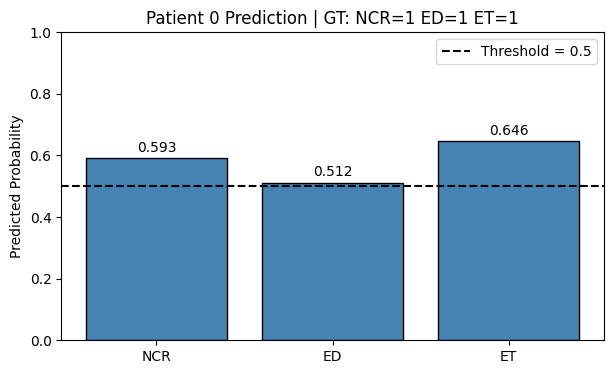

In [26]:
# CELL 25
@torch.no_grad()
def visualize_patient_prediction(model, dataset, idx, device):
    model.eval()

    vol, gt = dataset[idx]

    vol = vol.unsqueeze(0).to(device)

    with torch.cuda.amp.autocast(enabled=CFG['mixed_precision']):
        logits, _ = model(vol)

    probs = torch.sigmoid(logits).squeeze().float().cpu().numpy()

    gt = gt.numpy()

    plt.figure(figsize=(7, 4))

    colors = ['steelblue' if p >= 0.5 else 'salmon' for p in probs]

    bars = plt.bar(
        CLASS_NAMES,
        probs,
        color=colors,
        edgecolor='black'
    )

    plt.axhline(
        0.5,
        color='black',
        linestyle='--',
        label='Threshold = 0.5'
    )

    plt.ylim(0, 1)

    plt.ylabel('Predicted Probability')

    plt.title(
        f'Patient {idx} Prediction | '
        f'GT: NCR={int(gt[0])} ED={int(gt[1])} ET={int(gt[2])}'
    )

    for b, p in zip(bars, probs):
        plt.text(
            b.get_x() + b.get_width() / 2,
            p + 0.02,
            f'{p:.3f}',
            ha='center'
        )

    plt.legend()

    plt.show()


visualize_patient_prediction(
    model,
    test_dataset,
    idx=0,
    device=DEVICE
)

In [27]:
# CELL 26
results = {}

for i, lbl in enumerate(CLASS_NAMES):
    results[lbl] = {
        'precision': precision_score(
            test_labels[:, i],
            test_preds[:, i],
            zero_division=0
        ),
        'recall': recall_score(
            test_labels[:, i],
            test_preds[:, i],
            zero_division=0
        ),
        'f1': f1_score(
            test_labels[:, i],
            test_preds[:, i],
            zero_division=0
        ),
        'accuracy': accuracy_score(
            test_labels[:, i],
            test_preds[:, i]
        )
    }

    if len(np.unique(test_labels[:, i])) >= 2:
        results[lbl]['auroc'] = roc_auc_score(
            test_labels[:, i],
            test_probs[:, i]
        )
    else:
        results[lbl]['auroc'] = float('nan')

results_df = pd.DataFrame(results).T

results_df.index.name = 'Label'

print(results_df.round(4))

results_df.to_csv('/content/test_results_vit_b16_meanpool.csv')

       precision  recall      f1  accuracy   auroc
Label                                             
NCR       1.0000     1.0  1.0000    1.0000     NaN
ED        1.0000     1.0  1.0000    1.0000     NaN
ET        0.9464     1.0  0.9725    0.9464  0.2893


In [30]:
# CELL 27
exact_match_accuracy = (test_preds == test_labels).all(axis=1).mean()

print(f'Exact Match Accuracy: {exact_match_accuracy * 100:.2f}%')

Exact Match Accuracy: 94.64%


In [29]:
# Accuracy + AUROC score on validation set

val_loss, val_f1, val_preds, val_labels, val_probs = evaluate(
    model,
    val_loader,
    criterion,
    DEVICE
)

print(f'Validation Loss: {val_loss:.4f}')
print(f'Validation Macro F1: {val_f1:.4f}')

# Label-wise accuracy
for i, cls in enumerate(CLASS_NAMES):
    acc = accuracy_score(val_labels[:, i], val_preds[:, i])
    print(f'{cls} Accuracy: {acc:.4f}')

# Overall label accuracy
overall_acc = (val_preds == val_labels).mean()
print(f'Overall Label Accuracy: {overall_acc:.4f}')

# Exact match accuracy
exact_match_acc = (val_preds == val_labels).all(axis=1).mean()
print(f'Exact Match Accuracy: {exact_match_acc:.4f}')

# AUROC scores
auroc_scores = []

for i, cls in enumerate(CLASS_NAMES):
    if len(np.unique(val_labels[:, i])) >= 2:
        auroc = roc_auc_score(val_labels[:, i], val_probs[:, i])
        auroc_scores.append(auroc)
        print(f'{cls} AUROC: {auroc:.4f}')
    else:
        print(f'{cls} AUROC: Not available')

macro_auroc = np.mean(auroc_scores)
print(f'Macro AUROC: {macro_auroc:.4f}')

Validation Loss: 0.0377
Validation Macro F1: 0.9877
NCR Accuracy: 1.0000
ED Accuracy: 1.0000
ET Accuracy: 0.9286
Overall Label Accuracy: 0.9762
Exact Match Accuracy: 0.9286
NCR AUROC: Not available
ED AUROC: Not available
ET AUROC: 0.5889
Macro AUROC: 0.5889


In [31]:
# LOG LOSS, F1, AUROC, ACCURACY + AUROC CURVES

from sklearn.metrics import (
    log_loss,
    f1_score,
    accuracy_score,
    roc_auc_score,
    roc_curve,
    classification_report
)

# Choose validation or test loader
eval_loader = test_loader   # change to val_loader if you want validation

eval_loss, eval_f1, eval_preds, eval_labels, eval_probs = evaluate(
    model,
    eval_loader,
    criterion,
    DEVICE
)

print("=" * 60)
print("OVERALL METRICS")
print("=" * 60)

print(f"BCE Log Loss from model criterion: {eval_loss:.4f}")

# sklearn multilabel log loss
log_losses = []

for i, cls in enumerate(CLASS_NAMES):
    try:
        ll = log_loss(eval_labels[:, i], eval_probs[:, i], labels=[0, 1])
        log_losses.append(ll)
        print(f"{cls} Log Loss: {ll:.4f}")
    except Exception as e:
        print(f"{cls} Log Loss: Not available")

macro_log_loss = np.mean(log_losses)
print(f"Macro Log Loss: {macro_log_loss:.4f}")

# F1
macro_f1 = f1_score(eval_labels, eval_preds, average='macro', zero_division=0)
micro_f1 = f1_score(eval_labels, eval_preds, average='micro', zero_division=0)
weighted_f1 = f1_score(eval_labels, eval_preds, average='weighted', zero_division=0)

print(f"Macro F1: {macro_f1:.4f}")
print(f"Micro F1: {micro_f1:.4f}")
print(f"Weighted F1: {weighted_f1:.4f}")

# Accuracy
overall_label_accuracy = (eval_preds == eval_labels).mean()
exact_match_accuracy = (eval_preds == eval_labels).all(axis=1).mean()

print(f"Overall Label Accuracy: {overall_label_accuracy:.4f}")
print(f"Exact Match Accuracy: {exact_match_accuracy:.4f}")

for i, cls in enumerate(CLASS_NAMES):
    acc = accuracy_score(eval_labels[:, i], eval_preds[:, i])
    print(f"{cls} Accuracy: {acc:.4f}")

# AUROC
auroc_scores = []

print("=" * 60)
print("AUROC SCORES")
print("=" * 60)

for i, cls in enumerate(CLASS_NAMES):
    if len(np.unique(eval_labels[:, i])) >= 2:
        auroc = roc_auc_score(eval_labels[:, i], eval_probs[:, i])
        auroc_scores.append(auroc)
        print(f"{cls} AUROC: {auroc:.4f}")
    else:
        print(f"{cls} AUROC: Not available because only one class exists")

if len(auroc_scores) > 0:
    macro_auroc = np.mean(auroc_scores)
    print(f"Macro AUROC: {macro_auroc:.4f}")
else:
    print("Macro AUROC: Not available")

print("=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        eval_labels,
        eval_preds,
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0
    )
)

OVERALL METRICS
BCE Log Loss from model criterion: 0.0318
NCR Log Loss: 0.5248
ED Log Loss: 0.6696
ET Log Loss: 0.4691
Macro Log Loss: 0.5545
Macro F1: 0.9908
Micro F1: 0.9910
Weighted F1: 0.9912
Overall Label Accuracy: 0.9821
Exact Match Accuracy: 0.9464
NCR Accuracy: 1.0000
ED Accuracy: 1.0000
ET Accuracy: 0.9464
AUROC SCORES
NCR AUROC: Not available because only one class exists
ED AUROC: Not available because only one class exists
ET AUROC: 0.2893
Macro AUROC: 0.2893
CLASSIFICATION REPORT
              precision    recall  f1-score   support

         NCR     1.0000    1.0000    1.0000        56
          ED     1.0000    1.0000    1.0000        56
          ET     0.9464    1.0000    0.9725        53

   micro avg     0.9821    1.0000    0.9910       165
   macro avg     0.9821    1.0000    0.9908       165
weighted avg     0.9828    1.0000    0.9912       165
 samples avg     0.9821    1.0000    0.9893       165



NCR ROC curve skipped because only one class exists
ED ROC curve skipped because only one class exists


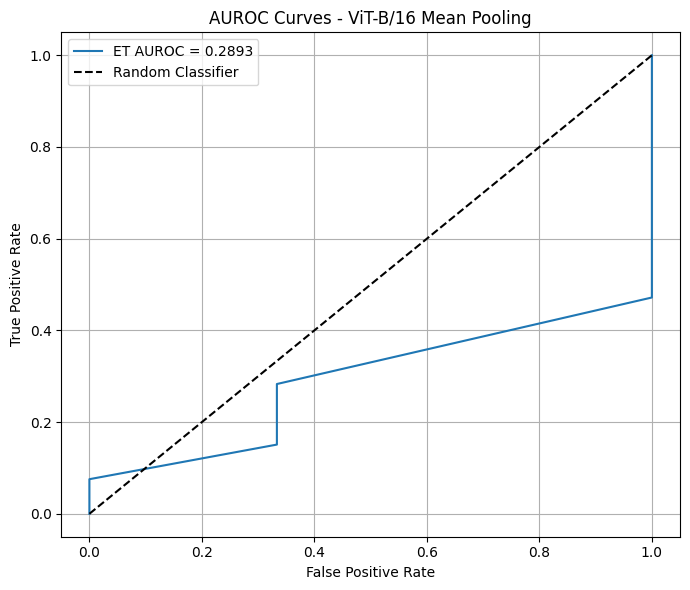

In [32]:
# AUROC CURVES

plt.figure(figsize=(7, 6))

for i, cls in enumerate(CLASS_NAMES):
    if len(np.unique(eval_labels[:, i])) >= 2:
        fpr, tpr, thresholds = roc_curve(eval_labels[:, i], eval_probs[:, i])
        auroc = roc_auc_score(eval_labels[:, i], eval_probs[:, i])

        plt.plot(fpr, tpr, label=f'{cls} AUROC = {auroc:.4f}')
    else:
        print(f'{cls} ROC curve skipped because only one class exists')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUROC Curves - ViT-B/16 Mean Pooling')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('/content/auroc_curves_vit_b16_meanpool.png', dpi=150)
plt.show()